In [ ]:
#Mohammad Shaad 202501100300156 AI C

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb

In [2]:
df = pd.read_csv('/content/creditcard (2).csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [3]:
scaler = StandardScaler()
df['std_amount'] = scaler.fit_transform(df[['Amount']])
df['std_time'] = scaler.fit_transform(df[['Time']])

In [4]:
df_filter = df.drop(columns=['Time', 'Amount'])

In [5]:
df_filter.sample(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,std_amount,std_time
9439,1.240619,0.362429,0.318717,0.709700,-0.137192,-0.529381,-0.161678,-0.078648,1.180004,-0.464205,...,-1.017629,0.096693,-0.116015,0.184709,0.061004,-0.058206,0.009350,0.0,-0.345395,0.199820
11524,1.245745,0.716944,0.465262,2.582250,0.193992,-0.297736,0.104623,-0.193915,0.566126,0.347288,...,-0.298620,-0.099935,-0.193003,0.601384,0.030622,-0.046009,0.006391,0.0,-0.350623,0.866486
8861,1.036178,-0.105397,0.203067,0.169406,0.882443,2.219703,-0.593719,0.536936,1.190338,-0.514554,...,-0.044151,0.010591,-2.203341,0.042408,0.474977,0.010695,-0.016079,0.0,-0.139637,0.000755
8588,-3.084163,-4.189527,2.348548,-1.256688,1.453284,-2.662021,-2.404357,0.193888,-0.577665,0.483384,...,-0.224350,0.730371,0.232219,0.496035,-0.224590,-0.141064,0.136965,0.0,0.483814,-0.059699
11337,1.285225,1.335819,-1.671419,1.742738,1.073445,-1.520790,0.612086,-0.384398,1.008365,-1.893719,...,-0.856852,-0.247487,-0.525239,0.870562,-0.298888,0.006704,0.083566,0.0,-0.345342,0.849786


In [6]:
# Remove rows having missing Class values
df = df.dropna(subset=['Class'])

# Convert target to integer
df['Class'] = df['Class'].astype(int)

X = df.drop(columns=['Class'])
y = df['Class']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
print(f"Original Training Set Size: {X_train.shape[0]}")
print(f"Original Training Fraud Count: {y_train.sum()}")

Original Training Set Size: 12748
Original Training Fraud Count: 58


In [9]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [10]:
print(f"Balanced Training Set Size (after SMOTE): {X_train_resampled.shape[0]}")
print(f"Balanced Training Fraud Count: {y_train_resampled.sum()}")

Balanced Training Set Size (after SMOTE): 25380
Balanced Training Fraud Count: 12690


In [11]:
model = xgb.XGBClassifier(n_estimators=100,max_depth=6,learning_rate=0.1,objective='binary:logistic',eval_metric='logloss', random_state=42,n_jobs=-1)

In [12]:
print("Training XGBoost model...")
model.fit(X_train_resampled, y_train_resampled)

Training XGBoost model...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [13]:
y_probs = model.predict_proba(X_test)[:, 1]

In [14]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1-Score: {f1:.4f} | "
        f"(TP: {tp}, FP: {fp}, FN: {fn})"
    )

Threshold: 0.1 | Precision: 0.7059 | Recall: 0.8000 | F1-Score: 0.7500 | (TP: 12, FP: 5, FN: 3)
Threshold: 0.3 | Precision: 0.7500 | Recall: 0.8000 | F1-Score: 0.7742 | (TP: 12, FP: 4, FN: 3)
Threshold: 0.5 | Precision: 0.7333 | Recall: 0.7333 | F1-Score: 0.7333 | (TP: 11, FP: 4, FN: 4)
Threshold: 0.7 | Precision: 0.7857 | Recall: 0.7333 | F1-Score: 0.7586 | (TP: 11, FP: 3, FN: 4)
Threshold: 0.9 | Precision: 0.7857 | Recall: 0.7333 | F1-Score: 0.7586 | (TP: 11, FP: 3, FN: 4)


<Figure size 1000x600 with 0 Axes>

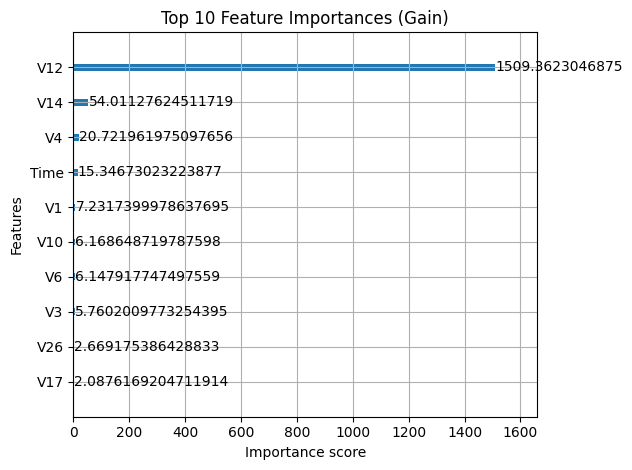

In [15]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, max_num_features=10, importance_type='gain', title='Top 10 Feature Importances (Gain)')
plt.tight_layout()
plt.show()